# Random Forest Pipeline – Credit Card Default Prediction
### IFTE0003 Group Coursework 2

## Cell 1 – Imports & Config

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import (train_test_split, RandomizedSearchCV,
                                     GridSearchCV, StratifiedKFold, cross_val_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, f1_score, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
from scipy.stats import randint
import joblib
import os

RANDOM_STATE = 42
TEST_SIZE    = 0.2
os.makedirs('rf_outputs', exist_ok=True)

print('All libraries imported successfully.')

All libraries imported successfully.


## Cell 2 – Load Dataset

In [24]:
dataset = fetch_ucirepo(id=350)
X = dataset.data.features.copy()
y = dataset.data.targets.copy().squeeze()

# Rename columns to meaningful names
col_names = [
    'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]
X.columns = col_names

print(f'Dataset shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')
print(f'Default rate: {y.mean():.2%}')
X.head()

Dataset shape: (30000, 23)
Target distribution:
Y
0    23364
1     6636
Name: count, dtype: int64
Default rate: 22.12%


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


## Cell 3 – Exploratory Data Analysis

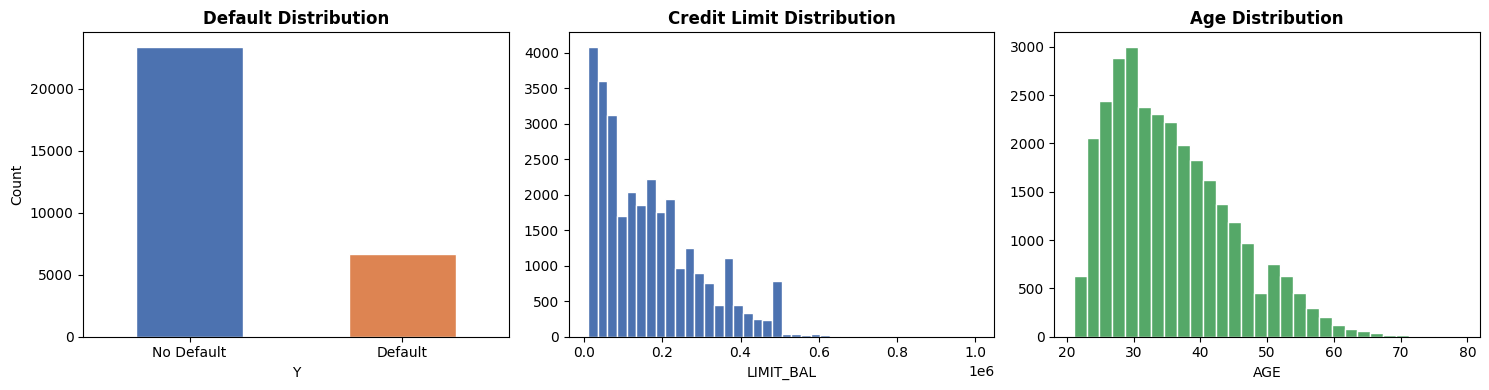

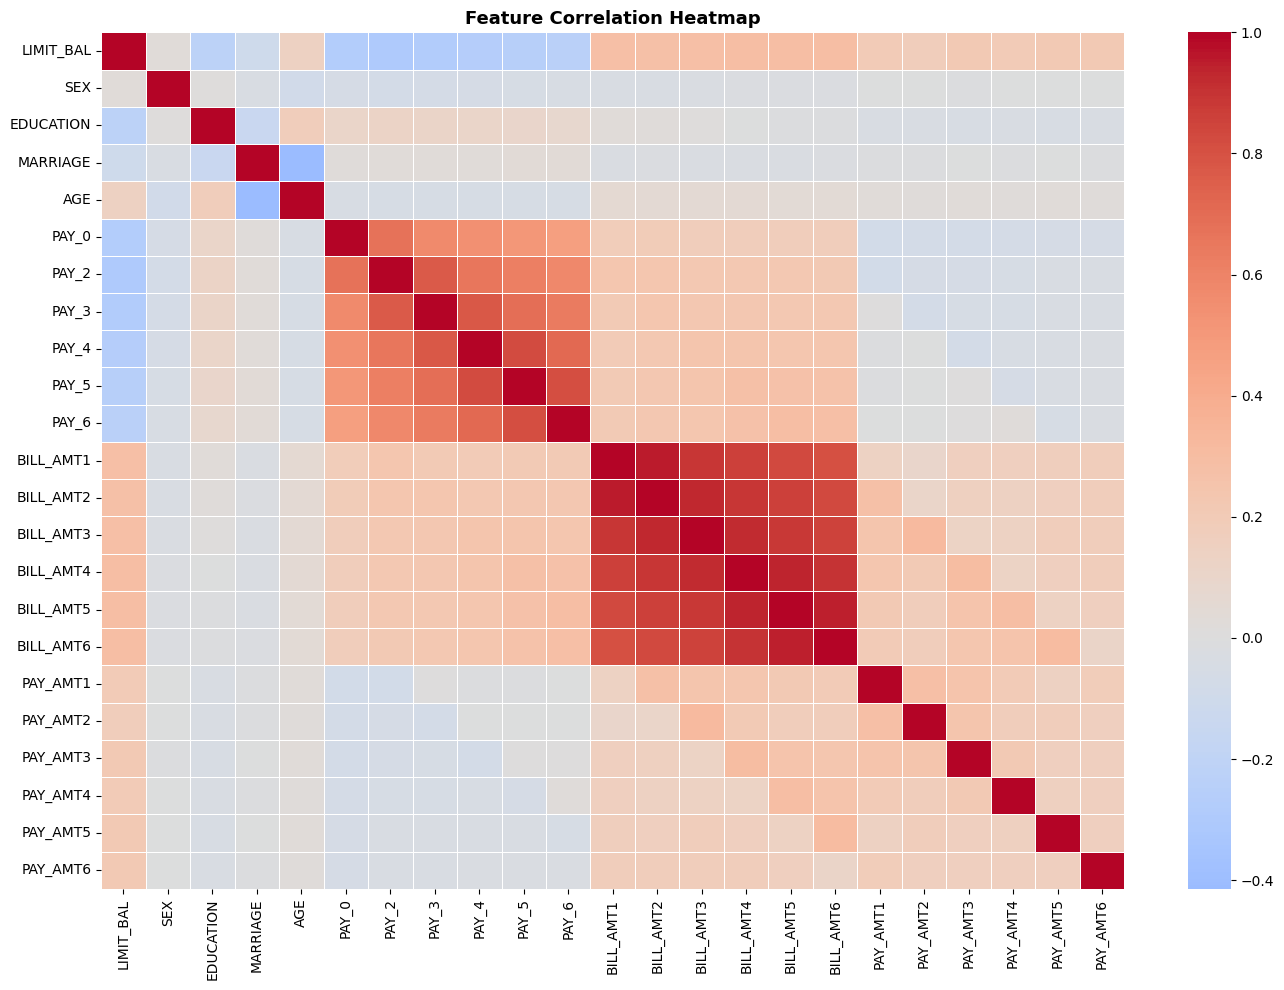

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

y.value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('Default Distribution', fontweight='bold')
axes[0].set_xticklabels(['No Default', 'Default'], rotation=0)
axes[0].set_ylabel('Count')

axes[1].hist(X['LIMIT_BAL'], bins=40, color='#4C72B0', edgecolor='white')
axes[1].set_title('Credit Limit Distribution', fontweight='bold')
axes[1].set_xlabel('LIMIT_BAL')

axes[2].hist(X['AGE'], bins=30, color='#55A868', edgecolor='white')
axes[2].set_title('Age Distribution', fontweight='bold')
axes[2].set_xlabel('AGE')

plt.tight_layout()
plt.savefig('rf_outputs/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(14, 10))
sns.heatmap(X.corr(), cmap='coolwarm', center=0, linewidths=0.5, annot=False)
plt.title('Feature Correlation Heatmap', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('rf_outputs/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 4 – Data Cleaning

In [26]:
print('Before cleaning:')
print(f'  EDUCATION unique values: {sorted(X["EDUCATION"].unique())}')
print(f'  MARRIAGE  unique values: {sorted(X["MARRIAGE"].unique())}')

# EDUCATION: values 0, 5, 6 are undefined in the dataset documentation — merge into category 4 (Other)
X['EDUCATION'] = X['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# MARRIAGE: value 0 is undefined — merge into category 3 (Other)
X['MARRIAGE'] = X['MARRIAGE'].replace({0: 3})

print('\nAfter cleaning:')
print(f'  EDUCATION unique values: {sorted(X["EDUCATION"].unique())}')
print(f'  MARRIAGE  unique values: {sorted(X["MARRIAGE"].unique())}')
print(f'\nDuplicate rows: {X.duplicated().sum()}')
print(f'Missing values: {X.isnull().sum().sum()}')

Before cleaning:
  EDUCATION unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
  MARRIAGE  unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

After cleaning:
  EDUCATION unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  MARRIAGE  unique values: [np.int64(1), np.int64(2), np.int64(3)]

Duplicate rows: 56
Missing values: 0


## Cell 5 – Feature Engineering

In [27]:
pay_cols    = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
bill_cols   = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
payamt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# Number of months with payment delay >= 1
X['DELINQUENCY_COUNT'] = (X[pay_cols] >= 1).sum(axis=1)

# Maximum payment delay across all months
X['MAX_DELINQUENCY'] = X[pay_cols].max(axis=1)

# Average bill amount
X['AVG_BILL_AMT'] = X[bill_cols].mean(axis=1)

# Average payment amount
X['AVG_PAY_AMT'] = X[payamt_cols].mean(axis=1)

# Repayment ratio: average payment / average bill (clipped to avoid extreme values)
X['REPAY_RATIO'] = (X['AVG_PAY_AMT'] / (X['AVG_BILL_AMT'].abs() + 1)).clip(upper=5)

# Credit utilisation: average bill / credit limit
X['UTILISATION'] = (X['AVG_BILL_AMT'] / (X['LIMIT_BAL'] + 1)).clip(upper=5)

print(f'Total features after engineering: {X.shape[1]}')

Total features after engineering: 29


## Cell 6 – Train / Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f'Train size: {X_train.shape[0]}  |  Default rate: {y_train.mean():.2%}')
print(f'Test  size: {X_test.shape[0]}   |  Default rate: {y_test.mean():.2%}')

Train size: 24000  |  Default rate: 22.12%
Test  size: 6000   |  Default rate: 22.12%


## Cell 7 – Baseline RF (class_weight='balanced')

In [29]:
baseline_rf = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
baseline_rf.fit(X_train, y_train)

y_pred_baseline  = baseline_rf.predict(X_test)
y_proba_baseline = baseline_rf.predict_proba(X_test)[:, 1]

print('Baseline RF Results:')
print(classification_report(y_test, y_pred_baseline, target_names=['No Default', 'Default']))
print(f'AUC-ROC:           {roc_auc_score(y_test, y_proba_baseline):.4f}')
print(f'Average Precision: {average_precision_score(y_test, y_proba_baseline):.4f}')

Baseline RF Results:
              precision    recall  f1-score   support

  No Default       0.83      0.95      0.89      4673
     Default       0.64      0.34      0.44      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.64      0.66      6000
weighted avg       0.79      0.81      0.79      6000

AUC-ROC:           0.7604
Average Precision: 0.5389


## Cell 8 – SMOTE Experiment

In [30]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f'After SMOTE — train size: {X_train_sm.shape[0]}  |  Default rate: {y_train_sm.mean():.2%}')

smote_rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
smote_rf.fit(X_train_sm, y_train_sm)

y_pred_smote  = smote_rf.predict(X_test)
y_proba_smote = smote_rf.predict_proba(X_test)[:, 1]

print('\nSMOTE RF Results:')
print(classification_report(y_test, y_pred_smote, target_names=['No Default', 'Default']))
print(f'AUC-ROC:           {roc_auc_score(y_test, y_proba_smote):.4f}')
print(f'Average Precision: {average_precision_score(y_test, y_proba_smote):.4f}')

After SMOTE — train size: 37382  |  Default rate: 50.00%

SMOTE RF Results:
              precision    recall  f1-score   support

  No Default       0.86      0.87      0.87      4673
     Default       0.52      0.49      0.50      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.68      0.68      6000
weighted avg       0.78      0.79      0.79      6000

AUC-ROC:           0.7507
Average Precision: 0.4979


## Cell 9 – Hyperparameter Tuning: RandomizedSearchCV
> Warning: this cell may take 5–15 minutes to run.

In [31]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_dist = {
    'n_estimators':      randint(100, 600),
    'max_depth':         [None, 5, 10, 15, 20, 25],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 10),
    'max_features':      ['sqrt', 'log2', 0.3, 0.5],
    'class_weight':      ['balanced', 'balanced_subsample'],
}

rand_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=50, scoring='roc_auc', cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
rand_search.fit(X_train, y_train)

print(f'Best params (random search): {rand_search.best_params_}')
print(f'Best CV AUC: {rand_search.best_score_:.4f}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params (random search): {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 0.3, 'min_samples_leaf': 8, 'min_samples_split': 5, 'n_estimators': 459}
Best CV AUC: 0.7850


## Cell 10 – Hyperparameter Tuning: GridSearchCV (fine search)

In [40]:
best = rand_search.best_params_

grid_params = {
    'n_estimators':      [max(50, best['n_estimators'] - 100),
                          best['n_estimators'],
                          best['n_estimators'] + 100],
    'max_depth':         [best['max_depth']],
    'min_samples_split': [max(2, best['min_samples_split'] - 2),
                          best['min_samples_split'],
                          best['min_samples_split'] + 2],
    'min_samples_leaf':  [max(1, best['min_samples_leaf'] - 1),
                          best['min_samples_leaf'],
                          best['min_samples_leaf'] + 1],
    'max_features':      [best['max_features']],
    'class_weight':      [best['class_weight']],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=grid_params, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f'Best params (grid search): {grid_search.best_params_}')
print(f'Best CV AUC: {grid_search.best_score_:.4f}')

best_rf = grid_search.best_estimator_

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params (grid search): {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 0.3, 'min_samples_leaf': 8, 'min_samples_split': 3, 'n_estimators': 559}
Best CV AUC: 0.7850


## Cell 11 – Final Model Evaluation

In [33]:
y_pred_final  = best_rf.predict(X_test)
y_proba_final = best_rf.predict_proba(X_test)[:, 1]

auc_final = roc_auc_score(y_test, y_proba_final)
ap_final  = average_precision_score(y_test, y_proba_final)
f1_final  = f1_score(y_test, y_pred_final)

print('Tuned RF – Final Results:')
print(classification_report(y_test, y_pred_final, target_names=['No Default', 'Default']))
print(f'AUC-ROC:           {auc_final:.4f}')
print(f'Average Precision: {ap_final:.4f}')
print(f'F1 (Default):      {f1_final:.4f}')

cv_scores = cross_val_score(best_rf, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f'\n5-Fold CV AUC (train): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

Tuned RF – Final Results:
              precision    recall  f1-score   support

  No Default       0.88      0.84      0.86      4673
     Default       0.51      0.59      0.54      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.80      0.78      0.79      6000

AUC-ROC:           0.7766
Average Precision: 0.5536
F1 (Default):      0.5437

5-Fold CV AUC (train): 0.7850 +/- 0.0049


## Cell 12 – Figure 1: ROC & Precision-Recall Curves

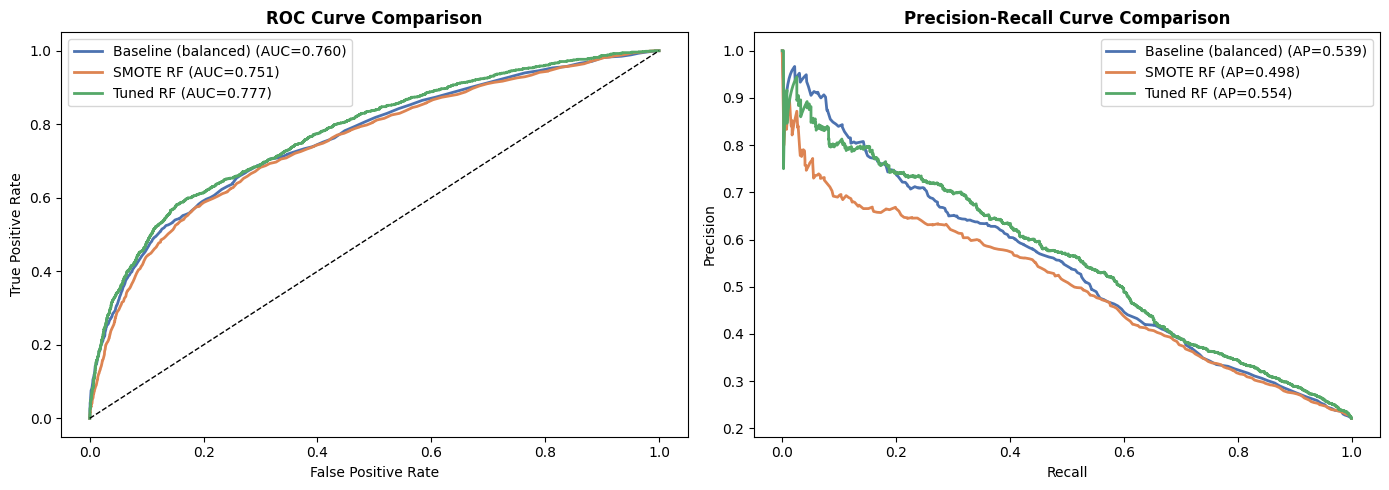

In [34]:
COLORS = {'baseline': '#4C72B0', 'smote': '#DD8452', 'final': '#55A868'}
models = [
    ('Baseline (balanced)', y_proba_baseline, COLORS['baseline']),
    ('SMOTE RF',            y_proba_smote,    COLORS['smote']),
    ('Tuned RF',            y_proba_final,    COLORS['final']),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, proba, color in models:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, lw=2)
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison', fontweight='bold')
ax.legend()

ax = axes[1]
for name, proba, color in models:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(rec, prec, label=f'{name} (AP={ap:.3f})', color=color, lw=2)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve Comparison', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('rf_outputs/fig1_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 13 – Figure 2: Confusion Matrix

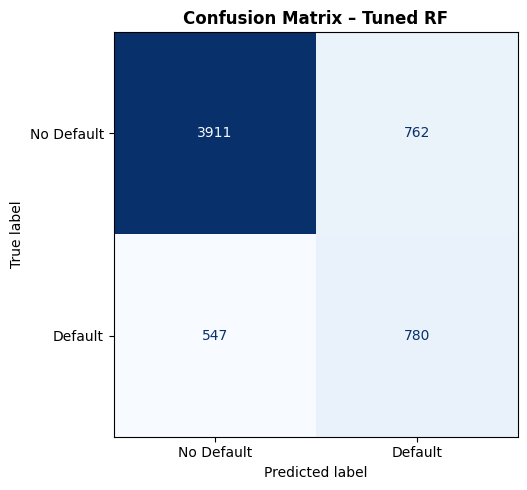

In [35]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix – Tuned RF', fontweight='bold')
plt.tight_layout()
plt.savefig('rf_outputs/fig2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 14 – Figure 3: Feature Importance (MDI + Permutation)

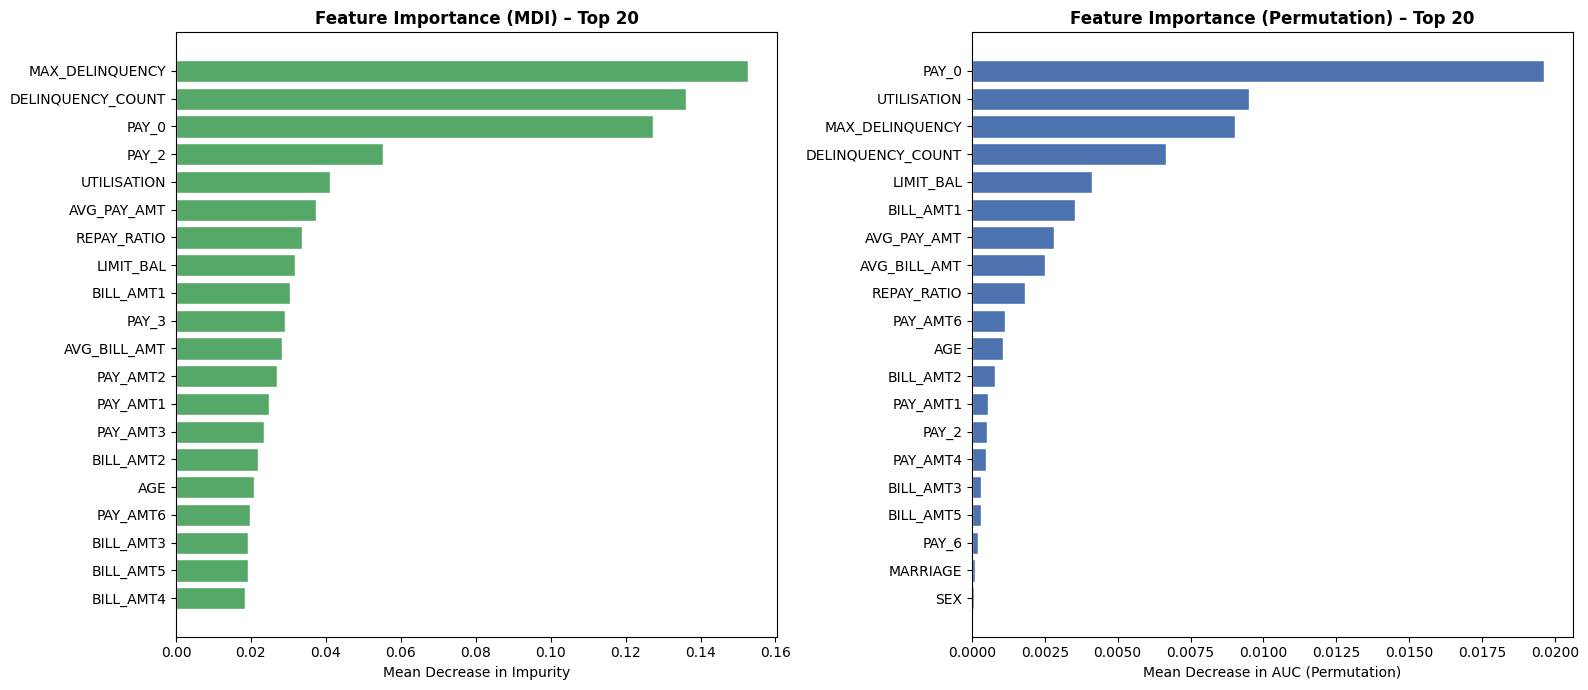

In [36]:
mdi_imp = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

perm_result = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=15, random_state=RANDOM_STATE, scoring='roc_auc', n_jobs=-1
)
perm_imp = pd.Series(perm_result.importances_mean, index=X.columns).sort_values(ascending=False)

TOP_N = 20
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

mdi_top = mdi_imp.head(TOP_N)
axes[0].barh(mdi_top.index[::-1], mdi_top.values[::-1], color=COLORS['final'], edgecolor='white')
axes[0].set_xlabel('Mean Decrease in Impurity')
axes[0].set_title(f'Feature Importance (MDI) – Top {TOP_N}', fontweight='bold')

perm_top = perm_imp.head(TOP_N)
axes[1].barh(perm_top.index[::-1], perm_top.values[::-1], color=COLORS['baseline'], edgecolor='white')
axes[1].set_xlabel('Mean Decrease in AUC (Permutation)')
axes[1].set_title(f'Feature Importance (Permutation) – Top {TOP_N}', fontweight='bold')

plt.tight_layout()
plt.savefig('rf_outputs/fig3_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 15 – Figure 4: Model Comparison Summary

Model Comparison Summary:


,AUC-ROC,Avg Precision,F1 (Default)
Model,,,
Baseline RF (balanced),0.7604,0.5389,0.4427
SMOTE RF,0.7507,0.4979,0.5039
Tuned RF,0.7766,0.5536,0.5437


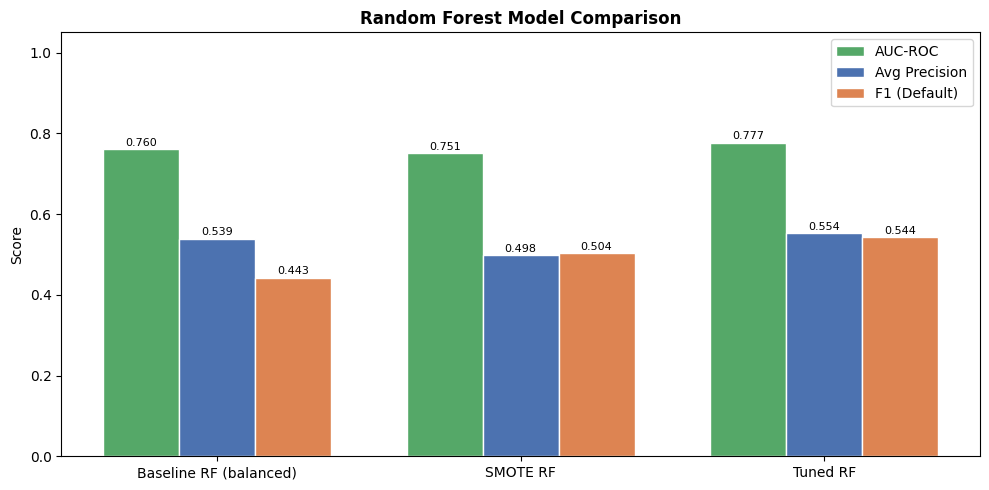

In [37]:
summary_df = pd.DataFrame({
    'Model': ['Baseline RF (balanced)', 'SMOTE RF', 'Tuned RF'],
    'AUC-ROC': [
        roc_auc_score(y_test, y_proba_baseline),
        roc_auc_score(y_test, y_proba_smote),
        auc_final
    ],
    'Avg Precision': [
        average_precision_score(y_test, y_proba_baseline),
        average_precision_score(y_test, y_proba_smote),
        ap_final
    ],
    'F1 (Default)': [
        f1_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_smote),
        f1_final
    ],
}).set_index('Model')

print('Model Comparison Summary:')
display(summary_df.round(4))
summary_df.to_csv('rf_outputs/model_comparison.csv')

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(summary_df))
width = 0.25
metric_colors = [COLORS['final'], COLORS['baseline'], COLORS['smote']]
for i, (col, color) in enumerate(zip(summary_df.columns, metric_colors)):
    bars = ax.bar(x + i*width, summary_df[col], width, label=col, color=color, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x + width)
ax.set_xticklabels(summary_df.index, fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Random Forest Model Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('rf_outputs/fig4_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 16 – Save Model & Results

In [38]:
joblib.dump(best_rf, 'rf_outputs/best_rf_model.pkl')

report_df = pd.DataFrame(
    classification_report(y_test, y_pred_final,
                          target_names=['No Default', 'Default'],
                          output_dict=True)
).T
report_df.to_csv('rf_outputs/classification_report.csv')

print('=' * 50)
print('All outputs saved to rf_outputs/')
print('=' * 50)
print(f'Final AUC-ROC:        {auc_final:.4f}')
print(f'Final Avg Precision:  {ap_final:.4f}')
print(f'Final F1 (Default):   {f1_final:.4f}')
print(f'Best parameters:      {grid_search.best_params_}')

All outputs saved to rf_outputs/
Final AUC-ROC:        0.7766
Final Avg Precision:  0.5536
Final F1 (Default):   0.5437
Best parameters:      {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 0.3, 'min_samples_leaf': 8, 'min_samples_split': 3, 'n_estimators': 559}


In [41]:
import shutil
import os

desktop = os.path.join(os.path.expanduser('~'), 'Desktop')
shutil.make_archive(os.path.join(desktop, 'rf_outputs'), 'zip', 'rf_outputs')
print('Saved to Desktop: rf_outputs.zip')

Saved to Desktop: rf_outputs.zip


In [42]:
import shutil
import os

desktop = os.path.join(os.path.expanduser('~'), 'Desktop')

# Create a temp folder with everything
os.makedirs('rf_package', exist_ok=True)

# Copy outputs folder
shutil.copytree('rf_outputs', 'rf_package/rf_outputs', dirs_exist_ok=True)

# Copy the notebook
import glob
notebooks = glob.glob('*.ipynb')
for nb in notebooks:
    shutil.copy(nb, 'rf_package/')

# Zip to desktop
shutil.make_archive(os.path.join(desktop, 'rf_package'), 'zip', 'rf_package')

# Clean up temp folder
shutil.rmtree('rf_package')

print('Saved to Desktop: rf_package.zip')
print(f'Notebooks included: {notebooks}')


Saved to Desktop: rf_package.zip
Notebooks included: []
